<a href="https://colab.research.google.com/github/ipavlopoulos/ndfu/blob/main/ndfu_synthetic_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Learning with nDFU on synthetic data

This notebook uses a `UnimodalLearner` class to test a simple idea: examples with pole-like annotator disagreement should not always be forced into the ordinary labels.

This notebook explains that learning setup with synthetic data. We create small numeric features and artificial annotator ratings. The goal is to make the learning logic visible.

## The idea

For every item, the original learner does three things:

1. Convert annotator scores to a histogram with `pdf`.
2. Compute nDFU on that histogram.
3. Build a target label:

`k+1` if `nDFU > threshold`, otherwise use the ordinary majority label.

For toxicity experiments, the ordinary labels are `civil` and `toxic`, so the K+1 learner has three labels: `civil`, `toxic`, and `k+1`. The extra class means: this item has structured disagreement and should be modeled separately.

In [1]:
#@title Setup
try:
    from ndfu import dfu, pdf
except ImportError:
    import sys
    import subprocess

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "git+https://github.com/ipavlopoulos/ndfu.git",
    ])
    from ndfu import dfu, pdf

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", context="notebook")
RNG = np.random.default_rng(2046)
SCALE = range(1, 6)


## Synthetic annotations

Each item gets two numeric features. The first feature is a simple toxicity signal: negative values tend to be toxic and positive values tend to be civil. The second feature is a disagreement signal: larger values make pole-like annotation patterns more likely.

We create three kinds of annotation distributions:

- `civil`: most ratings are high.
- `toxic`: most ratings are low.
- `polarized`: many annotators choose low ratings and many choose high ratings.

This gives us a controlled toy version of the problem in the application notebook.

In [2]:
#@title Generate synthetic examples
def make_scores(kind, n_annotators=12):
    if kind == "civil":
        return RNG.choice([3, 4, 5], size=n_annotators, p=[0.15, 0.35, 0.50]).tolist()
    if kind == "toxic":
        return RNG.choice([1, 2, 3], size=n_annotators, p=[0.50, 0.35, 0.15]).tolist()
    if kind == "polarized":
        # A small amount of middle mass keeps the toy data realistic while still pole-like.
        return RNG.choice([1, 2, 3, 4, 5], size=n_annotators, p=[0.42, 0.04, 0.08, 0.04, 0.42]).tolist()
    raise ValueError(kind)


def make_synthetic_dataset(n=900):
    rows = []
    for _ in range(n):
        signal = RNG.normal()
        disagreement_signal = RNG.normal()
        kind = "civil" if signal >= 0 else "toxic"

        # Items near the decision boundary and with high disagreement signal are pole-like.
        if abs(signal) < 0.75 and disagreement_signal > 0.05:
            kind = "polarized"

        scores = make_scores(kind)
        features = np.array([
            signal + RNG.normal(scale=0.30),
            disagreement_signal + RNG.normal(scale=0.30),
        ])
        rows.append({"x1_toxicity_signal": features[0], "x2_disagreement_signal": features[1], "kind": kind, "scores": scores})
    return pd.DataFrame(rows)


data = make_synthetic_dataset()
display(data.head())
display(data.kind.value_counts().rename("count").to_frame())


,x1_toxicity_signal,x2_disagreement_signal,kind,scores
0,0.074390,0.879135,polarized,"[3, 5, 5, 1, 1, 1, 3, 1, 5, 1, 1, 1]"
1,1.037013,0.451904,civil,"[5, 4, 3, 3, 5, 3, 5, 5, 5, 5, 5, 3]"
2,1.281746,-2.273248,civil,"[4, 3, 5, 4, 5, 3, 4, 5, 5, 4, 4, 3]"
3,-0.044980,2.253499,polarized,"[1, 1, 5, 4, 4, 1, 3, 1, 5, 3, 5, 4]"
4,1.126684,-0.635470,civil,"[4, 5, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5]"


,count
kind,
toxic,342
civil,327
polarized,231


## A compact learner

The class below is a small, synthetic-data version of `UnimodalLearner` from the application notebook. It keeps the same conceptual parts:

- compute `HIST` and `DFU` for each item,
- derive a binary majority label, here `civil` or `toxic`,
- create a K+1 target where high-nDFU items become `k+1`,
- train a normal binary baseline and a K+1 model.

In [3]:
#@title Synthetic version of UnimodalLearner
class SyntheticUnimodalLearner:
    def __init__(self, train, dev, test, threshold=0.0):
        self.train = train.copy()
        self.dev = dev.copy()
        self.test = test.copy()
        self.threshold = threshold

        for split in (self.train, self.dev, self.test):
            split["HIST"] = split.scores.apply(lambda scores: pdf(scores, SCALE))
            split["DFU"] = split.HIST.apply(dfu)
            split["binary_target"] = split.scores.apply(self.majority_label)
            split["kplus_target"] = split.apply(lambda row: self.kplus_label(row.DFU, row.scores), axis=1)

    @staticmethod
    def majority_label(scores):
        # Ratings below 3 are toxic. If at least half of annotators choose toxic ratings, label toxic.
        toxic_share = np.mean([score < 3 for score in scores])
        return "toxic" if toxic_share >= 0.5 else "civil"

    def kplus_label(self, score, scores):
        return "k+1" if score > self.threshold else self.majority_label(scores)

    @staticmethod
    def features(frame):
        return frame[["x1_toxicity_signal", "x2_disagreement_signal"]].to_numpy()

    def fit_binary_baseline(self):
        self.binary_model = LogisticRegression(max_iter=1000, random_state=2046)
        self.binary_model.fit(self.features(self.train), self.train.binary_target)
        return self.binary_model

    def fit_unimodal_only_baseline(self):
        clean_train = self.train[self.train.DFU == 0]
        self.clean_binary_model = LogisticRegression(max_iter=1000, random_state=2046)
        self.clean_binary_model.fit(self.features(clean_train), clean_train.binary_target)
        print(f"Removed {len(self.train) - len(clean_train)} high-nDFU training items from {len(self.train)} total items.")
        return self.clean_binary_model

    def fit_kplus_model(self):
        self.kplus_model = LogisticRegression(max_iter=1000, random_state=2046)
        self.kplus_model.fit(self.features(self.train), self.train.kplus_target)
        return self.kplus_model

    def binary_predictions_from_kplus(self, frame):
        # This mirrors the application notebook: when evaluating ordinary civil/toxic cases,
        # ignore the k+1 probability and choose between the remaining ordinary classes.
        probabilities = self.kplus_model.predict_proba(self.features(frame))
        classes = list(self.kplus_model.classes_)
        ordinary = [classes.index("civil"), classes.index("toxic")]
        ordinary_probabilities = probabilities[:, ordinary]
        ordinary_classes = np.array(["civil", "toxic"])
        return ordinary_classes[np.argmax(ordinary_probabilities, axis=1)]


## Split the data and inspect nDFU

The synthetic data has a hidden `kind` column only so we can check that nDFU is finding the intended pole-like cases. The learner itself only uses features and annotation scores.

,count,mean,min,max
kind,,,,
civil,196.0,0.029223,0.000000,0.600000
polarized,139.0,0.611425,0.111111,1.000000
toxic,205.0,0.025914,0.000000,0.666667


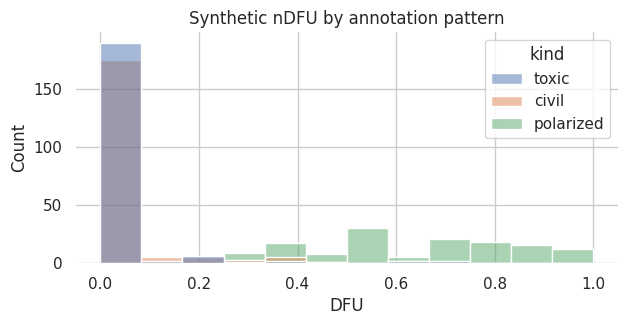

In [4]:
#@title Train/dev/test split and nDFU inspection
train, temp = train_test_split(data, test_size=0.40, random_state=2046, stratify=data.kind)
dev, test = train_test_split(temp, test_size=0.50, random_state=2046, stratify=temp.kind)

learner = SyntheticUnimodalLearner(train, dev, test, threshold=0.0)

summary = learner.train.groupby("kind").DFU.describe()[["count", "mean", "min", "max"]]
display(summary)

fig, ax = plt.subplots(figsize=(7, 3))
sns.histplot(data=learner.train, x="DFU", hue="kind", bins=12, multiple="layer", ax=ax)
ax.set_title("Synthetic nDFU by annotation pattern")
sns.despine(ax=ax, left=True, bottom=True)
plt.show()
plt.close(fig)


## How labels change under K+1 learning

The ordinary binary target collapses every item into `civil` or `toxic`. The K+1 target keeps ordinary labels for unimodal items, but sends high-nDFU items to the extra `k+1` class.

In [5]:
#@title Compare binary and K+1 targets
display(pd.crosstab(learner.train.binary_target, learner.train.kplus_target, margins=True))
display(pd.crosstab(learner.train.kind, learner.train.kplus_target, margins=True))


kplus_target,civil,k+1,toxic,All
binary_target,,,,
civil,176,91,0,267
toxic,0,85,188,273
All,176,176,188,540


kplus_target,civil,k+1,toxic,All
kind,,,,
civil,175,21,0,196
polarized,0,139,0,139
toxic,1,16,188,205
All,176,176,188,540


## Train the three models

We train three small logistic-regression models:

- `binary baseline`: learn `civil` vs. `toxic` from all examples.
- `unimodal-only baseline`: discard high-nDFU training examples and learn only from single-peak examples.
- `K+1 model`: learn `civil`, `toxic`, and `k+1` jointly.

In [6]:
#@title Fit models
learner.fit_binary_baseline()
learner.fit_unimodal_only_baseline()
learner.fit_kplus_model()
print("K+1 classes:", list(learner.kplus_model.classes_))


Removed 176 high-nDFU training items from 540 total items.
K+1 classes: ['civil', 'k+1', 'toxic']


## Evaluate K+1 detection

First, evaluate the three-class problem directly. In this synthetic notebook, `k+1` means the model predicts that an item has structured disagreement rather than a clean ordinary label.

In [7]:
#@title Three-class report
kplus_prediction = learner.kplus_model.predict(learner.features(learner.test))
print(classification_report(learner.test.kplus_target, kplus_prediction))

cm = confusion_matrix(learner.test.kplus_target, kplus_prediction, labels=list(learner.kplus_model.classes_))
display(pd.DataFrame(cm, index=learner.kplus_model.classes_, columns=learner.kplus_model.classes_))


              precision    recall  f1-score   support

       civil       0.82      0.86      0.84        63
         k+1       0.71      0.71      0.71        56
       toxic       0.84      0.80      0.82        61

    accuracy                           0.79       180
   macro avg       0.79      0.79      0.79       180
weighted avg       0.79      0.79      0.79       180



,civil,k+1,toxic
civil,54,9,0
k+1,7,40,9
toxic,5,7,49


## Evaluate ordinary labels on unpolarized items

The application notebook also asks whether the K+1 model still behaves well on ordinary civil/toxic examples. To do that, it evaluates on low-nDFU examples and ignores the `k+1` probability when choosing between `civil` and `toxic`.

In [8]:
#@title Binary reports on low-nDFU test examples
ordinary_test = learner.test[learner.test.DFU == 0]
gold = ordinary_test.binary_target

baseline_pred = learner.binary_model.predict(learner.features(ordinary_test))
clean_pred = learner.clean_binary_model.predict(learner.features(ordinary_test))
kplus_binary_pred = learner.binary_predictions_from_kplus(ordinary_test)

rows = []
for name, pred in [
    ("binary baseline", baseline_pred),
    ("unimodal-only baseline", clean_pred),
    ("K+1 model, k+1 ignored", kplus_binary_pred),
]:
    rows.append({"model": name, "macro_f1": f1_score(gold, pred, average="macro")})

display(pd.DataFrame(rows).sort_values("macro_f1", ascending=False))
print("Binary baseline")
print(classification_report(gold, baseline_pred))
print("K+1 model with k+1 probability ignored")
print(classification_report(gold, kplus_binary_pred))


,model,macro_f1
0,binary baseline,0.919018
1,unimodal-only baseline,0.919018
2,"K+1 model, k+1 ignored",0.919018


Binary baseline
              precision    recall  f1-score   support

       civil       0.88      0.97      0.92        63
       toxic       0.96      0.87      0.91        61

    accuracy                           0.92       124
   macro avg       0.92      0.92      0.92       124
weighted avg       0.92      0.92      0.92       124

K+1 model with k+1 probability ignored
              precision    recall  f1-score   support

       civil       0.88      0.97      0.92        63
       toxic       0.96      0.87      0.91        61

    accuracy                           0.92       124
   macro avg       0.92      0.92      0.92       124
weighted avg       0.92      0.92      0.92       124



## The threshold controls how many items become K+1

The original application tries several nDFU thresholds. Lower thresholds send more examples to `k+1`; higher thresholds keep more examples in the ordinary labels.

,threshold,kplus_share
0,0.0,0.325926
1,0.1,0.324074
2,0.2,0.288889
3,0.3,0.262963
4,0.4,0.218519
5,0.5,0.162963
6,0.6,0.127778
7,0.7,0.096296
8,0.8,0.051852
9,0.9,0.022222


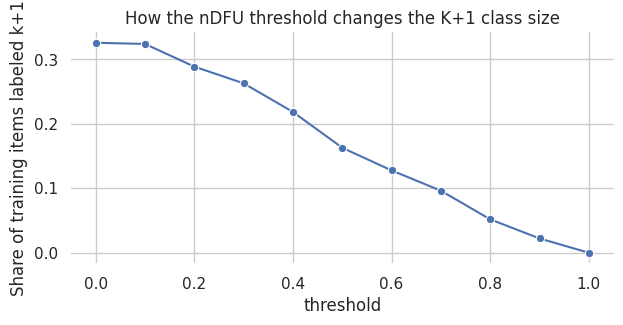

In [9]:
#@title K+1 support by nDFU threshold
thresholds = np.linspace(0, 1, 11)
support = []
for threshold in thresholds:
    labels = learner.train.apply(
        lambda row: "k+1" if row.DFU > threshold else row.binary_target,
        axis=1,
    )
    support.append({"threshold": threshold, "kplus_share": np.mean(labels == "k+1")})

support = pd.DataFrame(support)
display(support)

fig, ax = plt.subplots(figsize=(7, 3))
sns.lineplot(data=support, x="threshold", y="kplus_share", marker="o", ax=ax)
ax.set_title("How the nDFU threshold changes the K+1 class size")
ax.set_ylabel("Share of training items labeled k+1")
sns.despine(ax=ax, left=True, bottom=True)
plt.show()
plt.close(fig)


## Takeaway

The learner is not just a classifier trick. It encodes a modeling choice: if annotators form poles, the item may represent a different phenomenon than ordinary civil/toxic examples. nDFU supplies the signal for that choice, and K+1 learning gives the model an explicit place to put structured disagreement.